# PPC \#3 - Cálculo Numérico Aplicado

## Problema

Neste notebook, será resolvido numericamente o problema de condução de calor unidimensional transiente em uma parede plana, usando:

- método das diferenças finitas;
- esquema implícito de evolução no tempo;
- algoritmo de Thomas para sistemas tridiagonais;
- comparação com a solução exata no caso sem geração interna;
- extensão posterior para o caso com geração interna.

O problema será tratado inicialmente sem geração interna e, em seguida, com geração interna.

## 1. Caso sem geração interna

Para o caso sem geração interna, a equação governante é:

$$
\frac{\partial T}{\partial t}
=
\alpha \frac{\partial^2 T}{\partial x^2}
$$

Nesse problema, a temperatura depende da posição e do tempo:

$$
T = T(x,t)
$$

O objetivo é calcular a evolução da temperatura no domínio unidimensional ao longo do tempo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Discretização do domínio

O método das diferenças finitas substitui o domínio contínuo por uma malha de pontos:

$$
x_0, x_1, x_2, \ldots, x_{N-1}
$$

Em cada ponto da malha, armazena-se a temperatura em instantes discretos:

$$
T_i^p
$$

Nessa notação, o índice $i$ representa a posição espacial e o índice $p$ representa o instante de tempo.

In [2]:
# Parâmetros físicos iniciais de teste
alpha = 1.0e-5      # Difusividade térmica [m²/s]
k = 15.0            # Condutividade térmica [W/(m K)]
h = 100.0           # Coeficiente convectivo [W/(m² K)]

L = 0.05            # Comprimento característico [m]
T_initial = 500.0   # Temperatura inicial [K]
T_inf = 300.0       # Temperatura do fluido externo [K]

# Parâmetros numéricos
n_nodes = 51
dt = 1.0
t_final = 300.0

x = np.linspace(0, L, n_nodes)
dx = x[1] - x[0]

print(f"dx = {dx:.6e} m")
print(f"Número de nós = {n_nodes}")

dx = 1.000000e-03 m
Número de nós = 51


## 3. Esquema implícito de diferenças finitas

Para a derivada temporal, usa-se:

$$
\frac{\partial T}{\partial t}
\approx
\frac{T_i^{p+1}-T_i^p}{\Delta t}
$$

Para a segunda derivada espacial, usa-se a aproximação centrada:

$$
\frac{\partial^2 T}{\partial x^2}
\approx
\frac{T_{i+1}^{p+1}-2T_i^{p+1}+T_{i-1}^{p+1}}{\Delta x^2}
$$

Como o esquema é implícito, os termos espaciais são avaliados no instante novo, isto é, no passo $p+1$.

## 4. Forma algébrica para os nós internos

Define-se o parâmetro numérico:

$$
r = \frac{\alpha \Delta t}{\Delta x^2}
$$

Substituindo as aproximações na equação governante e reorganizando os termos, obtém-se:

$$
-rT_{i-1}^{p+1}
+
(1+2r)T_i^{p+1}
-
rT_{i+1}^{p+1}
=
T_i^p
$$

Essa equação mostra que cada nó depende apenas do nó anterior, dele mesmo e do nó seguinte. Por isso, o sistema linear gerado é tridiagonal.

## 5. Condições de contorno

Na extremidade esquerda, considera-se simetria adiabática. A equação discretizada fica:

$$
(1+2r)T_0^{p+1} - 2rT_1^{p+1} = T_0^p
$$

Na extremidade direita, considera-se convecção com o fluido externo. A equação discretizada fica:

$$
-2rT_{N-2}^{p+1}
+
(1+2r+2rBi_{\Delta x})T_{N-1}^{p+1}
=
T_{N-1}^{p}
+
2rBi_{\Delta x}T_{\infty}
$$

em que:

$$
Bi_{\Delta x} = \frac{h\Delta x}{k}
$$

## 6. Algoritmo de Thomas

Como o sistema linear é tridiagonal, ele será resolvido pelo algoritmo de Thomas.

A matriz tridiagonal é representada por três vetores:

- subdiagonal inferior;
- diagonal principal;
- superdiagonal superior.

Com isso, evita-se armazenar e manipular uma matriz completa cheia de zeros, como seria na decomposição LU, que ocuparia significativamente mais espaço de memória e demandaria muito mais operações aritméticas.

In [3]:
def thomas_algorithm(lower, diag, upper, rhs):
    """
    Resolve um sistema tridiagonal usando o algoritmo de Thomas.

    lower: subdiagonal. Use lower[0] = 0.
    diag: diagonal principal.
    upper: superdiagonal. Use upper[-1] = 0.
    rhs: vetor do lado direito.

    Retorna:
        x: vetor solução.
    """

    n = len(diag)

    a = lower.copy()
    b = diag.copy()
    c = upper.copy()
    d = rhs.copy()

    # Eliminação progressiva
    for i in range(1, n):
        m = a[i] / b[i - 1]
        b[i] = b[i] - m * c[i - 1]
        d[i] = d[i] - m * d[i - 1]

    # Substituição regressiva
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]

    return x

In [4]:
# Teste simples do algoritmo de Thomas

lower_test = np.array([0.0, -1.0, -1.0, -1.0])
diag_test = np.array([2.04, 2.04, 2.04, 2.04])
upper_test = np.array([-1.0, -1.0, -1.0, 0.0])
rhs_test = np.array([40.8, 0.8, 0.8, 200.8])

x_test = thomas_algorithm(lower_test, diag_test, upper_test, rhs_test)

print(x_test)

[ 65.96983437  93.77846211 124.53822833 159.47952369]


## 7. Montagem do sistema implícito

A cada passo de tempo, será montado um sistema linear tridiagonal.

Os vetores `lower`, `diag` e `upper` representam a matriz dos coeficientes. O vetor `rhs` representa o lado direito do sistema.

Depois de montar o sistema, ele é resolvido pelo algoritmo de Thomas.

In [5]:
def build_implicit_system_no_generation(T_old, alpha, k, h, L, dt, T_inf):
    """
    Monta o sistema tridiagonal para o problema 1D transiente sem geração interna.

    Condições de contorno:
        x = 0 -> simetria adiabática
        x = L -> convecção
    """

    n = len(T_old)
    dx = L / (n - 1)

    r = alpha * dt / dx**2
    Bi_dx = h * dx / k

    lower = np.zeros(n)
    diag = np.zeros(n)
    upper = np.zeros(n)
    rhs = np.zeros(n)

    # Nó 0: simetria adiabática
    diag[0] = 1 + 2 * r
    upper[0] = -2 * r
    rhs[0] = T_old[0]

    # Nós internos
    for i in range(1, n - 1):
        lower[i] = -r
        diag[i] = 1 + 2 * r
        upper[i] = -r
        rhs[i] = T_old[i]

    # Nó final: convecção
    lower[-1] = -2 * r
    diag[-1] = 1 + 2 * r + 2 * r * Bi_dx
    upper[-1] = 0
    rhs[-1] = T_old[-1] + 2 * r * Bi_dx * T_inf

    return lower, diag, upper, rhs

In [6]:
def solve_heat_1d_no_generation(
    alpha,
    k,
    h,
    L,
    T_initial,
    T_inf,
    n_nodes,
    dt,
    t_final,
):
    """
    Resolve a condução transiente 1D sem geração interna usando:
        - diferenças finitas;
        - esquema implícito;
        - algoritmo de Thomas.
    """

    x = np.linspace(0, L, n_nodes)
    T = np.ones(n_nodes) * T_initial

    n_steps = int(t_final / dt)

    history = []
    times = []

    save_interval = max(1, n_steps // 30)

    for step in range(n_steps + 1):
        t = step * dt

        if step == 0 or step % save_interval == 0:
            history.append(T.copy())
            times.append(t)

        lower, diag, upper, rhs = build_implicit_system_no_generation(
            T_old=T,
            alpha=alpha,
            k=k,
            h=h,
            L=L,
            dt=dt,
            T_inf=T_inf,
        )

        T = thomas_algorithm(lower, diag, upper, rhs)

    return x, np.array(times), np.array(history), T

## 8. Execução do caso sem geração interna

Nesta etapa, o solver é executado usando os parâmetros definidos anteriormente. O resultado será armazenado para posterior comparação com a solução exata.

In [7]:
x, times, history, T_final = solve_heat_1d_no_generation(
    alpha=alpha,
    k=k,
    h=h,
    L=L,
    T_initial=T_initial,
    T_inf=T_inf,
    n_nodes=n_nodes,
    dt=dt,
    t_final=t_final,
)

print("Temperatura final:")
print(T_final)

Temperatura final:
[446.40486086 446.39609461 446.36979691 446.32597092 446.26462188
 446.18575712 446.0893861  445.97552035 445.8441735  445.69536126
 445.52910147 445.34541401 445.14432089 444.92584616 444.69001599
 444.43685861 444.16640431 443.87868549 443.57373658 443.2515941
 442.9122966  442.5558847  442.18240109 441.79189046 441.38439957
 440.95997721 440.51867419 440.06054335 439.58563953 439.0940196
 438.58574242 438.06086884 437.5194617  436.96158584 436.38730804
 435.79669707 435.18982365 434.56676045 433.92758206 433.27236503
 432.60118782 431.91413078 431.2112762  430.49270824 429.75851295
 429.00877824 428.2435939  427.46305156 426.66724468 425.85626858
 425.03022037]


## 9. Visualização dos perfis de temperatura

A seguir, são mostrados os perfis de temperatura ao longo da parede para diferentes instantes de tempo.

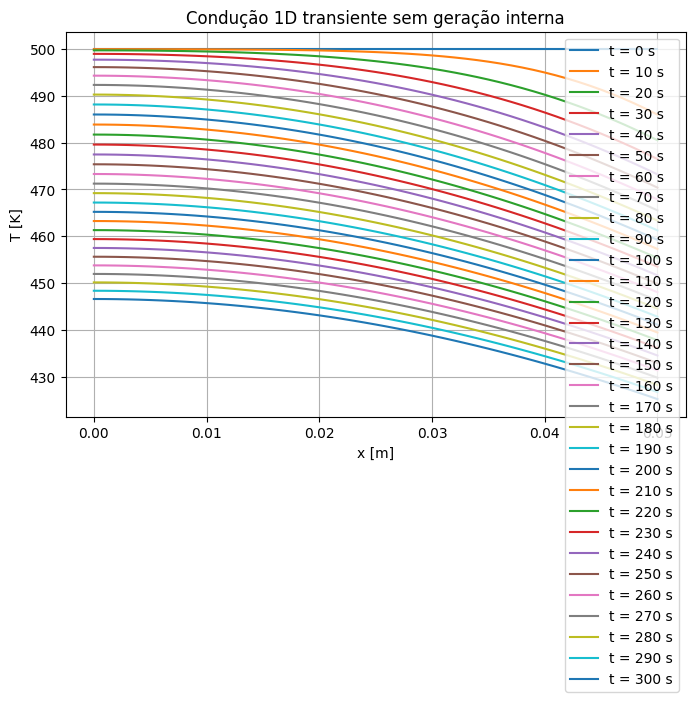

In [8]:
plt.figure(figsize=(8, 5))

for i, t in enumerate(times):
    plt.plot(x, history[i], label=f"t = {t:.0f} s")

plt.xlabel("x [m]")
plt.ylabel("T [K]")
plt.title("Condução 1D transiente sem geração interna")
plt.legend()
plt.grid(True)
plt.show()

## 10. Validação com a solução exata

Para validar a solução numérica do caso sem geração interna, compara-se o resultado obtido por diferenças finitas com a solução exata apresentada no enunciado.

A solução exata é escrita em termos da temperatura adimensional:

$$
\theta = \frac{T - T_\infty}{T_i - T_\infty}
$$

do número de Fourier:

$$
Fo = \frac{\alpha t}{L^2}
$$

e da posição adimensional:

$$
x^\ast = \frac{x}{L}
$$

Os autovalores da solução são obtidos pela equação característica:

$$
\lambda_n \tan(\lambda_n) = Bi
$$

em que:

$$
Bi = \frac{hL}{k}
$$

A comparação será feita no tempo final da simulação.

In [9]:
def find_lambda_roots(Bi, n_roots=30, tol=1e-12, max_iter=100):
    """
    Calcula as primeiras raízes positivas da equação:
        lambda * tan(lambda) = Bi

    As raízes estão nos intervalos:
        ((n-1)pi, (n-1/2)pi)
    para n = 1, 2, 3, ...
    """

    roots = []

    for n in range(1, n_roots + 1):
        a = (n - 1) * np.pi + 1e-9
        b = (n - 0.5) * np.pi - 1e-9

        def f(lam):
            return lam * np.tan(lam) - Bi

        fa = f(a)
        fb = f(b)

        # Bisseção
        for _ in range(max_iter):
            c = 0.5 * (a + b)
            fc = f(c)

            if abs(fc) < tol or abs(b - a) < tol:
                break

            if fa * fc < 0:
                b = c
                fb = fc
            else:
                a = c
                fa = fc

        roots.append(c)

    return np.array(roots)


def exact_solution_no_generation(x, t, alpha, k, h, L, T_initial, T_inf, n_terms=30):
    """
    Solução exata adimensional para a condução transiente 1D sem geração interna,
    com simetria adiabática em x=0 e convecção em x=L.
    """

    Bi = h * L / k
    Fo = alpha * t / L**2
    x_star = x / L

    lambdas = find_lambda_roots(Bi, n_roots=n_terms)

    theta = np.zeros_like(x_star, dtype=float)

    for lam in lambdas:
        coefficient = 4 * np.sin(lam) / (2 * lam + np.sin(2 * lam))
        theta += coefficient * np.cos(lam * x_star) * np.exp(-lam**2 * Fo)

    T_exact = T_inf + theta * (T_initial - T_inf)

    return T_exact

Agora comparando...

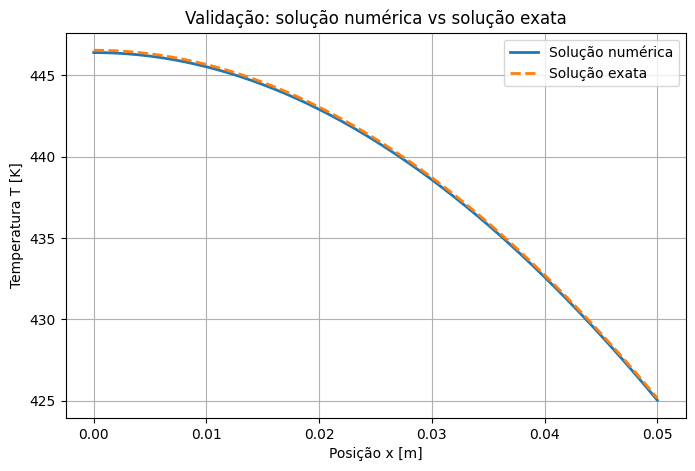

Erro máximo absoluto = 1.429686e-01 K
Erro médio absoluto = 1.359909e-01 K


In [10]:
t_compare = t_final

T_exact_final = exact_solution_no_generation(
    x=x,
    t=t_compare,
    alpha=alpha,
    k=k,
    h=h,
    L=L,
    T_initial=T_initial,
    T_inf=T_inf,
    n_terms=50,
)

plt.figure(figsize=(8, 5))

plt.plot(x, T_final, label="Solução numérica", linewidth=2)
plt.plot(x, T_exact_final, "--", label="Solução exata", linewidth=2)

plt.xlabel("Posição x [m]")
plt.ylabel("Temperatura T [K]")
plt.title("Validação: solução numérica vs solução exata")
plt.legend()
plt.grid(True)
plt.show()

erro_max = np.max(np.abs(T_final - T_exact_final))
erro_medio = np.mean(np.abs(T_final - T_exact_final))

print(f"Erro máximo absoluto = {erro_max:.6e} K")
print(f"Erro médio absoluto = {erro_medio:.6e} K")

A comparação entre a solução numérica e a solução exata permite validar a implementação do método das diferenças finitas para o caso sem geração interna.

A boa concordância entre as curvas indica que o esquema implícito, a montagem do sistema tridiagonal e o algoritmo de Thomas foram implementados de forma consistente.

As diferenças observadas estão associadas à discretização espacial, ao passo de tempo e ao truncamento da série usada na solução exata.

## 11. Caso com geração interna

No item anterior, foi resolvido o problema sem geração interna. Agora, acrescenta-se o termo de geração interna de energia ao modelo.

A equação governante passa a ser:

$$
\frac{\partial T}{\partial t}
=
\alpha \frac{\partial^2 T}{\partial x^2}
+
\frac{\dot{q}}{\rho C_p}
$$

Nessa equação, $\dot{q}$ representa a taxa de geração interna de energia por unidade de volume, $\rho$ é a massa específica e $C_p$ é o calor específico.

O objetivo desta etapa é modificar a solução numérica já desenvolvida, mantendo a mesma malha, o mesmo passo de tempo, o esquema implícito e o algoritmo de Thomas.

## 12. Discretização com geração interna

No esquema implícito, a parte difusiva da equação continua igual ao caso sem geração. A diferença é que o termo de geração interna acrescenta uma parcela ao lado direito do sistema.

Para os nós internos, a equação discretizada fica:

$$
-rT_{i-1}^{p+1}
+
(1+2r)T_i^{p+1}
-
rT_{i+1}^{p+1}
=
T_i^p
+
\frac{\dot{q}\Delta t}{\rho C_p}
$$

em que:

$$
r = \frac{\alpha \Delta t}{\Delta x^2}
$$

Assim, a matriz dos coeficientes permanece a mesma do caso sem geração interna. O que muda é apenas o vetor do lado direito do sistema linear.

## 13. Condições de contorno com geração interna

Na extremidade com simetria adiabática, acrescenta-se o termo de geração ao lado direito:

$$
(1+2r)T_0^{p+1}
-
2rT_1^{p+1}
=
T_0^p
+
\frac{\dot{q}\Delta t}{\rho C_p}
$$

Na extremidade com convecção, a equação fica:

$$
-2rT_{N-2}^{p+1}
+
(1+2r+2rBi_{\Delta x})T_{N-1}^{p+1}
=
T_{N-1}^{p}
+
2rBi_{\Delta x}T_{\infty}
+
\frac{\dot{q}\Delta t}{\rho C_p}
$$

com:

$$
Bi_{\Delta x} = \frac{h\Delta x}{k}
$$

In [11]:
def build_implicit_system_with_generation(
    T_old,
    alpha,
    k,
    h,
    L,
    dt,
    T_inf,
    rho,
    cp,
    q_dot,
):
    """
    Monta o sistema tridiagonal para o problema 1D transiente
    com geração interna.

    Condições de contorno:
        x = 0 -> simetria adiabática
        x = L -> convecção

    O algoritmo de Thomas será usado depois para resolver o sistema.
    """

    n = len(T_old)
    dx = L / (n - 1)

    r = alpha * dt / dx**2
    Bi_dx = h * dx / k

    # Incremento de temperatura associado à geração interna
    source_term = q_dot * dt / (rho * cp)

    lower = np.zeros(n)
    diag = np.zeros(n)
    upper = np.zeros(n)
    rhs = np.zeros(n)

    # Nó 0: simetria adiabática
    diag[0] = 1 + 2 * r
    upper[0] = -2 * r
    rhs[0] = T_old[0] + source_term

    # Nós internos
    for i in range(1, n - 1):
        lower[i] = -r
        diag[i] = 1 + 2 * r
        upper[i] = -r
        rhs[i] = T_old[i] + source_term

    # Nó final: convecção
    lower[-1] = -2 * r
    diag[-1] = 1 + 2 * r + 2 * r * Bi_dx
    upper[-1] = 0
    rhs[-1] = T_old[-1] + 2 * r * Bi_dx * T_inf + source_term

    return lower, diag, upper, rhs

In [12]:
def solve_heat_1d_with_generation(
    alpha,
    k,
    h,
    L,
    T_initial,
    T_inf,
    n_nodes,
    dt,
    t_final,
    rho,
    cp,
    q_dot,
):
    """
    Resolve a condução transiente 1D com geração interna usando:
        - diferenças finitas;
        - esquema implícito;
        - algoritmo de Thomas.
    """

    x = np.linspace(0, L, n_nodes)
    T = np.ones(n_nodes) * T_initial

    n_steps = int(t_final / dt)

    history = []
    times = []

    save_interval = max(1, n_steps // 30)

    for step in range(n_steps + 1):
        t = step * dt

        if step == 0 or step % save_interval == 0:
            history.append(T.copy())
            times.append(t)

        lower, diag, upper, rhs = build_implicit_system_with_generation(
            T_old=T,
            alpha=alpha,
            k=k,
            h=h,
            L=L,
            dt=dt,
            T_inf=T_inf,
            rho=rho,
            cp=cp,
            q_dot=q_dot,
        )

        T = thomas_algorithm(lower, diag, upper, rhs)

    return x, np.array(times), np.array(history), T

## 14. Validação no limite assintótico

Para validar a implementação com geração interna, utiliza-se o limite assintótico:

$$
\dot{q} \to 0
$$

Nesse limite, o termo de geração interna desaparece, e a solução com geração deve se aproximar da solução sem geração:

$$
T_{\text{com geração}} \to T_{\text{sem geração}}
$$

Assim, compara-se a solução obtida com `q_dot = 0` e com valores muito pequenos de `q_dot` contra a solução sem geração interna.

In [13]:
# Propriedades adicionais necessárias para o termo de geração
rho = 7800.0   # massa específica [kg/m³]
cp = 500.0     # calor específico [J/(kg K)]

# Solução sem geração, usando a função do item 1
x_no_gen, times_no_gen, history_no_gen, T_final_no_gen = solve_heat_1d_no_generation(
    alpha=alpha,
    k=k,
    h=h,
    L=L,
    T_initial=T_initial,
    T_inf=T_inf,
    n_nodes=n_nodes,
    dt=dt,
    t_final=t_final,
)

# Solução com geração interna nula
x_q0, times_q0, history_q0, T_final_q0 = solve_heat_1d_with_generation(
    alpha=alpha,
    k=k,
    h=h,
    L=L,
    T_initial=T_initial,
    T_inf=T_inf,
    n_nodes=n_nodes,
    dt=dt,
    t_final=t_final,
    rho=rho,
    cp=cp,
    q_dot=0.0,
)

max_diff_q0 = np.max(np.abs(T_final_q0 - T_final_no_gen))

print(f"Diferença máxima para q_dot = 0: {max_diff_q0:.6e} K")

Diferença máxima para q_dot = 0: 0.000000e+00 K


In [14]:
q_dot_values = [1.0e-6, 1.0e-3, 1.0, 1.0e3]

for q_dot_test in q_dot_values:
    _, _, _, T_final_test = solve_heat_1d_with_generation(
        alpha=alpha,
        k=k,
        h=h,
        L=L,
        T_initial=T_initial,
        T_inf=T_inf,
        n_nodes=n_nodes,
        dt=dt,
        t_final=t_final,
        rho=rho,
        cp=cp,
        q_dot=q_dot_test,
    )

    max_diff = np.max(np.abs(T_final_test - T_final_no_gen))

    print(f"q_dot = {q_dot_test:.1e} W/m³ -> diferença máxima = {max_diff:.6e} K")

q_dot = 1.0e-06 W/m³ -> diferença máxima = 7.526069e-11 K
q_dot = 1.0e-03 W/m³ -> diferença máxima = 6.762554e-08 K
q_dot = 1.0e+00 W/m³ -> diferença máxima = 6.762335e-05 K
q_dot = 1.0e+03 W/m³ -> diferença máxima = 6.762335e-02 K


A diferença entre a solução com geração interna e a solução sem geração deve diminuir conforme `q_dot` se aproxima de zero.

Isso confirma que o termo de geração foi implementado de forma coerente, pois o modelo com geração recupera o modelo sem geração no limite assintótico.

In [15]:
q_dot_example = 2.0e6  # geração interna [W/m³]

x_gen, times_gen, history_gen, T_final_gen = solve_heat_1d_with_generation(
    alpha=alpha,
    k=k,
    h=h,
    L=L,
    T_initial=T_initial,
    T_inf=T_inf,
    n_nodes=n_nodes,
    dt=dt,
    t_final=t_final,
    rho=rho,
    cp=cp,
    q_dot=q_dot_example,
)

print("Temperatura final com geração interna:")
print(T_final_gen)

Temperatura final com geração interna:
[581.65155422 581.6359168  581.58900335 581.51081026 581.40133154
 581.26055882 581.0884813  580.88508582 580.65035681 580.38427631
 580.08682398 579.75797709 579.39771054 579.00599682 578.58280609
 578.12810609 577.64186223 577.12403753 576.57459266 575.99348594
 575.38067334 574.73610846 574.05974261 573.35152472 572.61140141
 571.83931699 571.03521344 570.19903045 569.33070539 568.43017336
 567.49736715 566.5322173  565.53465207 564.50459746 563.44197722
 562.34671287 561.21872367 560.0579267  558.86423679 557.6375666
 556.37782656 555.08492496 553.75876791 552.39925933 551.00630104
 549.5797927  548.11963185 546.62571392 545.09793224 543.53617806
 541.94034056]


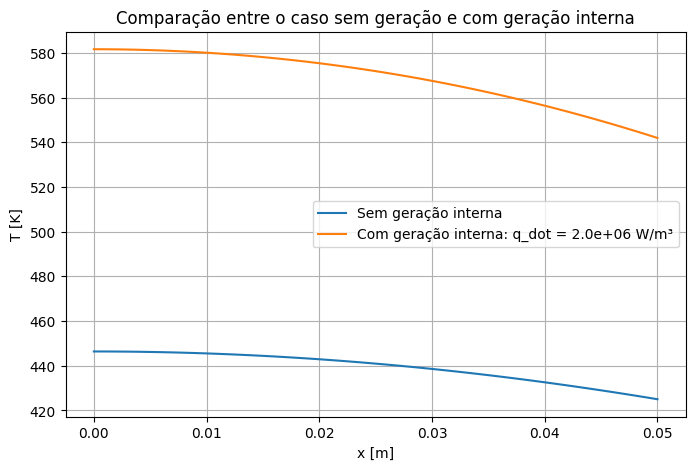

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(x_no_gen, T_final_no_gen, label="Sem geração interna")
plt.plot(x_gen, T_final_gen, label=f"Com geração interna: q_dot = {q_dot_example:.1e} W/m³")

plt.xlabel("x [m]")
plt.ylabel("T [K]")
plt.title("Comparação entre o caso sem geração e com geração interna")
plt.legend()
plt.grid(True)
plt.show()

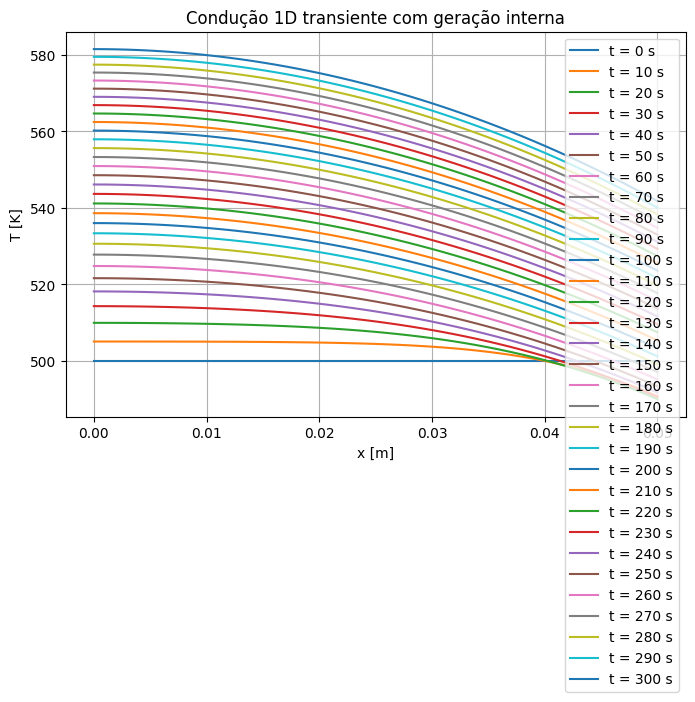

In [17]:
plt.figure(figsize=(8, 5))

for i, t in enumerate(times_gen):
    plt.plot(x_gen, history_gen[i], label=f"t = {t:.0f} s")

plt.xlabel("x [m]")
plt.ylabel("T [K]")
plt.title("Condução 1D transiente com geração interna")
plt.legend()
plt.grid(True)
plt.show()

## 15. Hora do show: Representações visuais da solução

Nesta etapa, são testadas diferentes formas de representação visual da solução numérica.

A solução calculada representa a temperatura ao longo da posição e do tempo:

$$
T = T(x,t)
$$

## 16. Mapa de calor da solução com geração interna

O mapa de calor permite visualizar a temperatura simultaneamente em função da posição e do tempo. Nesse tipo de gráfico, o eixo horizontal representa a posição, o eixo vertical representa o tempo e a cor representa a temperatura.

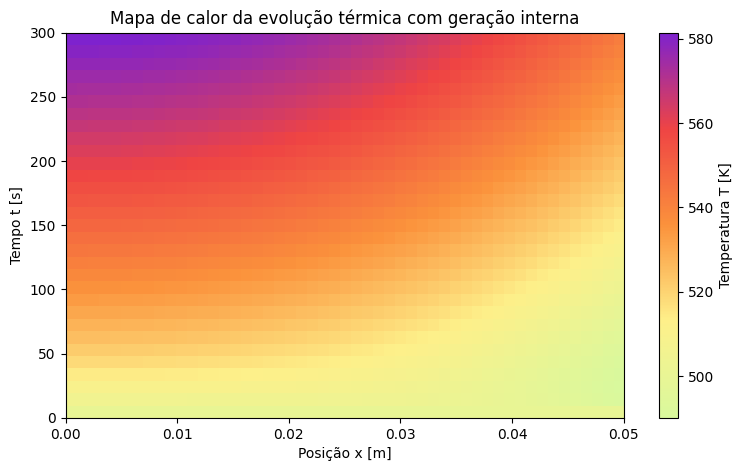

In [18]:
from matplotlib.colors import LinearSegmentedColormap

# Escala personalizada:
# menor temperatura -> verde/amarelo claro
# temperatura intermediária -> laranja/vermelho
# maior temperatura -> roxo
thermal_cmap = LinearSegmentedColormap.from_list(
    "thermal_custom",
    [
        "#d9f99d",  # verde claro
        "#fef08a",  # amarelo claro
        "#fb923c",  # laranja
        "#ef4444",  # vermelho
        "#7e22ce"   # roxo
    ]
)

plt.figure(figsize=(9, 5))

plt.imshow(
    history_gen,
    aspect="auto",
    origin="lower",
    extent=[x_gen[0], x_gen[-1], times_gen[0], times_gen[-1]],
    cmap=thermal_cmap
)

plt.colorbar(label="Temperatura T [K]")
plt.xlabel("Posição x [m]")
plt.ylabel("Tempo t [s]")
plt.title("Mapa de calor da evolução térmica com geração interna")
plt.show()

## 17. Mapa de calor comparativo: sem geração e com geração interna

A visualização anterior mostrou apenas o caso com geração interna. Agora, para comparar diretamente os dois cenários, serão plotados dois mapas de calor lado a lado:

- caso sem geração interna;
- caso com geração interna.

A ideia é comparar a distribuição de temperatura no espaço e no tempo:

$$
T = T(x,t)
$$

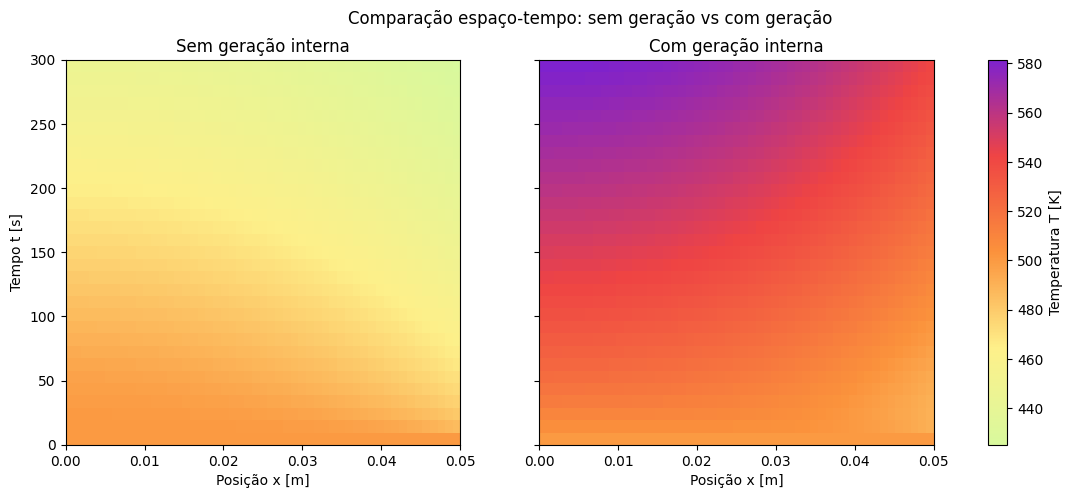

In [19]:
# Mapa de calor comparativo: sem geração vs com geração

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Usa a mesma escala de cores nos dois gráficos
vmin = min(np.min(history_no_gen), np.min(history_gen))
vmax = max(np.max(history_no_gen), np.max(history_gen))

# Caso sem geração interna
img0 = axes[0].imshow(
    history_no_gen,
    aspect="auto",
    origin="lower",
    extent=[x_no_gen[0], x_no_gen[-1], times_no_gen[0], times_no_gen[-1]],
    cmap=thermal_cmap,
    vmin=vmin,
    vmax=vmax
)

axes[0].set_title("Sem geração interna")
axes[0].set_xlabel("Posição x [m]")
axes[0].set_ylabel("Tempo t [s]")

# Caso com geração interna
img1 = axes[1].imshow(
    history_gen,
    aspect="auto",
    origin="lower",
    extent=[x_gen[0], x_gen[-1], times_gen[0], times_gen[-1]],
    cmap=thermal_cmap,
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title("Com geração interna")
axes[1].set_xlabel("Posição x [m]")

# Barra de cores comum aos dois gráficos
fig.colorbar(img1, ax=axes, label="Temperatura T [K]")

plt.suptitle("Comparação espaço-tempo: sem geração vs com geração")
plt.show()

A comparação lado a lado evidencia o efeito da geração interna de energia.

Como os dois mapas usam a mesma escala de cores, é possível comparar diretamente os níveis de temperatura em cada caso. O caso com geração interna apresenta temperaturas mais elevadas ao longo do domínio, pois há uma fonte de energia distribuída no interior do material. Interessante também é observar que em x = 0,0 (centro do objeto), onde não há convecção, a temperatura sobe mais, pela menor troca de calor com o meio em conjunto com a geração interna (um potencializando o outro). Já sem isso, é possível ver mais uniformidade no todo, apesar de haver diferença de troca de calor.

Essa visualização complementa os gráficos de perfil, pois mostra a evolução completa da solução ao longo do espaço e do tempo.

## 18. Animação comparativa da evolução temporal

Como visualização complementar, será gerada uma animação dos mapas de calor para os casos sem e com geração interna.

In [20]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt

# Número de quadros disponíveis nos dois casos
n_frames = min(len(times_no_gen), len(times_gen))

# Recorta os históricos para garantir o mesmo número de quadros
history_no_gen_anim = history_no_gen[:n_frames]
history_gen_anim = history_gen[:n_frames]

# Escala comum de temperatura para comparação justa
vmin_common = min(np.min(history_no_gen_anim), np.min(history_gen_anim))
vmax_common = max(np.max(history_no_gen_anim), np.max(history_gen_anim))

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

# Cada faixa é uma matriz 1 x N
strip_no_gen = history_no_gen_anim[0][np.newaxis, :]
strip_gen = history_gen_anim[0][np.newaxis, :]

img0 = axes[0].imshow(
    strip_no_gen,
    aspect="auto",
    extent=[x_no_gen[0], x_no_gen[-1], 0, 1],
    cmap=thermal_cmap,
    vmin=vmin_common,
    vmax=vmax_common
)

img1 = axes[1].imshow(
    strip_gen,
    aspect="auto",
    extent=[x_gen[0], x_gen[-1], 0, 1],
    cmap=thermal_cmap,
    vmin=vmin_common,
    vmax=vmax_common
)

axes[0].set_title("Sem geração interna")
axes[1].set_title("Com geração interna")

for ax in axes:
    ax.set_yticks([])
    ax.set_ylabel("Corpo")
    ax.grid(False)

axes[1].set_xlabel("Posição x [m]")

# Barra de cores comum
fig.colorbar(img1, ax=axes, label="Temperatura T [K]")

time_text = fig.text(
    0.5,
    0.95,
    "",
    ha="center",
    va="center",
    fontsize=12
)

def update(frame):
    strip_no_gen = history_no_gen_anim[frame][np.newaxis, :]
    strip_gen = history_gen_anim[frame][np.newaxis, :]

    img0.set_data(strip_no_gen)
    img1.set_data(strip_gen)

    time_text.set_text(f"Distribuição térmica no corpo em t = {times_gen[frame]:.1f} s")

    return img0, img1, time_text

animation = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=250,
    blit=False
)

plt.close(fig)

HTML(animation.to_jshtml())

# Item 4 — Escolha de valores realistas para o problema

Nesta etapa, são escolhidos valores físicos plausíveis para representar, de forma simplificada, o comportamento térmico de um combustível sólido de reator nuclear.

O material considerado será o dióxido de urânio, usualmente representado por:

$$
UO_2
$$
## 4.1 Parâmetros físicos adotados

Foram adotados valores representativos para o combustível sólido, o fluido de resfriamento e a geometria simplificada do problema.

| Grandeza | Símbolo | Valor adotado | Unidade | Comentário |
|---|---:|---:|---:|---|
| Massa específica do UO₂ | $\rho$ | 10970 | kg/m³ | valor típico de referência para UO₂ |
| Calor específico | $C_p$ | 300 | J/(kg K) | valor aproximado para simulação |
| Condutividade térmica | $k$ | 2.5 | W/(m K) | valor representativo em alta temperatura |
| Temperatura inicial | $T_i$ | 900 | K | combustível inicialmente quente |
| Temperatura do fluido | $T_\infty$ | 580 | K | ordem de grandeza de fluido refrigerante quente |
| Coeficiente convectivo | $h$ | 10000 | W/(m² K) | convecção intensa em escoamento forçado |
| Comprimento característico | $L$ | 0.004 | m | dimensão simplificada associada à espessura/radio do combustível |
| Geração volumétrica | $\dot{q}$ | $5.0 \times 10^7$ | W/m³ | valor reduzido para manter a simulação estável e visualmente interpretável |

A difusividade térmica é calculada por:

$$
\alpha = \frac{k}{\rho C_p}
$$

In [21]:
rho_real = 10970.0       # massa específica do UO2 [kg/m³]
cp_real = 300.0          # calor específico aproximado [J/(kg K)]
k_real = 2.5             # condutividade térmica em alta temperatura [W/(m K)]

alpha_real = k_real / (rho_real * cp_real)

h_real = 10000.0         # coeficiente convectivo aproximado [W/(m² K)]

L_real = 0.004           # comprimento característico [m]

T_initial_real = 900.0   # temperatura inicial do combustível [K]
T_inf_real = 580.0       # temperatura do fluido externo [K]

q_dot_real = 5.0e7       # geração interna volumétrica [W/m³]

n_nodes_real = 81
dt_real = 0.02
t_final_real = 5.0

print(f"alpha_real = {alpha_real:.6e} m²/s")

alpha_real = 7.596475e-07 m²/s


## 4.2 Comentário sobre a geração interna

Em uma vareta combustível real, a potência costuma ser discutida em termos de potência linear, isto é, potência por unidade de comprimento.

Uma estimativa simplificada da geração volumétrica pode ser feita por:

$$
\dot{q} \approx \frac{q'}{\pi R^2}
$$

In [22]:
# Estimativa ilustrativa da geração volumétrica a partir de uma potência linear

q_linear_example = 40_000.0  # potência linear ilustrativa [W/m]
R_example = 0.004            # raio efetivo [m]

q_dot_estimated = q_linear_example / (np.pi * R_example**2)

print(f"Geração volumétrica estimada = {q_dot_estimated:.3e} W/m³")
print(f"Geração volumétrica adotada no modelo = {q_dot_real:.3e} W/m³")

Geração volumétrica estimada = 7.958e+08 W/m³
Geração volumétrica adotada no modelo = 5.000e+07 W/m³


O valor estimado a partir de uma potência linear típica pode ser bastante alto para um modelo unidimensional simplificado.

Por isso, nesta simulação foi utilizado um valor menor de geração volumétrica:

$$
\dot{q} = 5.0 \times 10^7\ \text{W/m}^3
$$

In [23]:
# Cenário realista simplificado - sem geração interna

x_real_no_gen, times_real_no_gen, history_real_no_gen, T_final_real_no_gen = solve_heat_1d_no_generation(
    alpha=alpha_real,
    k=k_real,
    h=h_real,
    L=L_real,
    T_initial=T_initial_real,
    T_inf=T_inf_real,
    n_nodes=n_nodes_real,
    dt=dt_real,
    t_final=t_final_real,
)

# Cenário realista simplificado - com geração interna

x_real_gen, times_real_gen, history_real_gen, T_final_real_gen = solve_heat_1d_with_generation(
    alpha=alpha_real,
    k=k_real,
    h=h_real,
    L=L_real,
    T_initial=T_initial_real,
    T_inf=T_inf_real,
    n_nodes=n_nodes_real,
    dt=dt_real,
    t_final=t_final_real,
    rho=rho_real,
    cp=cp_real,
    q_dot=q_dot_real,
)

print("Cenário realista calculado com sucesso.")
print(f"Sem geração: history_real_no_gen.shape = {history_real_no_gen.shape}")
print(f"Com geração: history_real_gen.shape = {history_real_gen.shape}")

Cenário realista calculado com sucesso.
Sem geração: history_real_no_gen.shape = (32, 81)
Com geração: history_real_gen.shape = (32, 81)


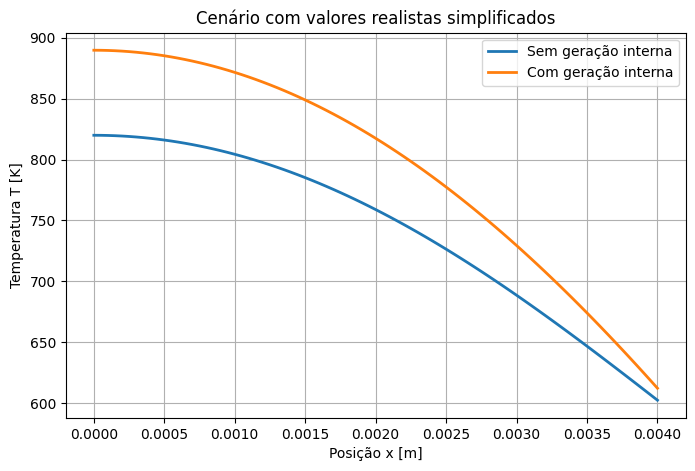

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_real_no_gen,
    T_final_real_no_gen,
    label="Sem geração interna",
    linewidth=2
)

plt.plot(
    x_real_gen,
    T_final_real_gen,
    label="Com geração interna",
    linewidth=2
)

plt.xlabel("Posição x [m]")
plt.ylabel("Temperatura T [K]")
plt.title("Cenário com valores realistas simplificados")
plt.legend()
plt.grid(True)
plt.show()

A comparação mostra o efeito da geração interna sobre o perfil final de temperatura.

No caso sem geração interna, o corpo tende ao resfriamento devido à convecção com o fluido externo.

No caso com geração interna, a temperatura permanece mais elevada, pois o termo fonte adiciona energia ao domínio durante a evolução temporal.

O resultado é coerente com a interpretação física do problema.

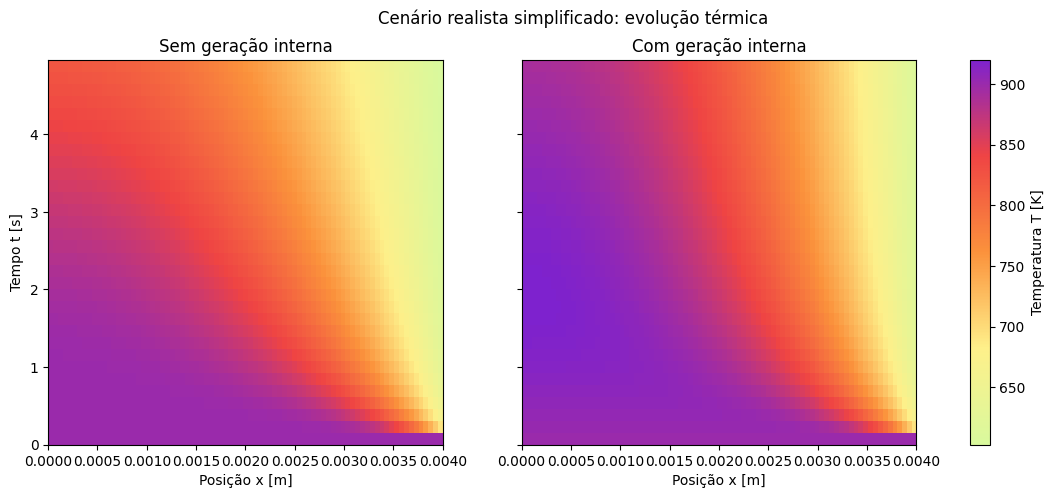

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

vmin_real = min(np.min(history_real_no_gen), np.min(history_real_gen))
vmax_real = max(np.max(history_real_no_gen), np.max(history_real_gen))

img0 = axes[0].imshow(
    history_real_no_gen,
    aspect="auto",
    origin="lower",
    extent=[
        x_real_no_gen[0],
        x_real_no_gen[-1],
        times_real_no_gen[0],
        times_real_no_gen[-1],
    ],
    cmap=thermal_cmap,
    vmin=vmin_real,
    vmax=vmax_real,
)

axes[0].set_title("Sem geração interna")
axes[0].set_xlabel("Posição x [m]")
axes[0].set_ylabel("Tempo t [s]")

img1 = axes[1].imshow(
    history_real_gen,
    aspect="auto",
    origin="lower",
    extent=[
        x_real_gen[0],
        x_real_gen[-1],
        times_real_gen[0],
        times_real_gen[-1],
    ],
    cmap=thermal_cmap,
    vmin=vmin_real,
    vmax=vmax_real,
)

axes[1].set_title("Com geração interna")
axes[1].set_xlabel("Posição x [m]")

fig.colorbar(img1, ax=axes, label="Temperatura T [K]")

plt.suptitle("Cenário realista simplificado: evolução térmica")
plt.show()

## 4.3 Referências utilizadas para os valores físicos

Os valores adotados no cenário realista simplificado foram escolhidos com base em ordens de grandeza reportadas para materiais combustíveis nucleares, especialmente o dióxido de urânio (UO₂), e em bases de propriedades termofísicas usadas em engenharia nuclear.

Referências consultadas:

- International Atomic Energy Agency (IAEA). *Thermophysical Properties of Materials for Nuclear Engineering: A Tutorial and Collection of Data*. Vienna: IAEA, 2008. Disponível em: https://www-pub.iaea.org/MTCD/Publications/PDF/IAEA-THPH_web.pdf

- International Atomic Energy Agency (IAEA). *Thermophysical Properties Database of Materials for Light Water Reactors and Heavy Water Reactors*. IAEA-TECDOC-1496, 2006. Disponível em: https://www-pub.iaea.org/MTCD/Publications/PDF/te_1496_web.pdf

- Fink, J. K. *Thermophysical properties of uranium dioxide*. Journal of Nuclear Materials, 279(1), 1–18, 2000. DOI: https://doi.org/10.1016/S0022-3115(99)00273-1
